In [1]:
using Pkg
Pkg.activate(joinpath(@__DIR__, "..", ".."))  # go up three levels (from PauliSampling.jl\numerics\quantumboltzmannmachine\ceofficient_truncation to to PauliSampling.jl)

  Activating project at `~/Desktop/PauliSampling.jl`


In [2]:
# Load all packages
using PauliSampling, PauliPropagation, Plots, LinearAlgebra, ProgressMeter, Statistics, Printf, Distributions, Random, Optimisers, ReverseDiff, MAT, BenchmarkTools, IterTools, StatsBase, LaTeXStrings, Measures, CSV, DataFrames, JSON3, Dates, PyPlot, Optim, Combinatorics
using Plots: plot
using LinearAlgebra: norm

## Thermal state generation

In [3]:
nq = 16

16

In [4]:
field_scale = 0.5       # typical order of magnitude for 1-local terms
coupling_scale = 0.3    # typical order for 2-local terms
rng = MersenneTwister(30)

# Initialize all parameters randomly
params = parameters(
    :heisenberg_fields, nq;
    init = :randn,
    field_scale = field_scale,
    coupling_scale = coupling_scale,
    rng = rng
)

beta = 1
# beta = rand(rng, Uniform(1, 10))
qbm_H_paulis = makehamiltonian(params; connectivity=:nearest, periodic=false) * beta;

In [5]:
circuit, theta = paulistringtocircuit(qbm_H_paulis);

In [6]:
num_layers_qbm = nq * 10;

exact state

In [ ]:
rho_exact = makethermalstate(nq, circuit, theta, num_layers_qbm;
                            max_weight=nq, min_abs_coeff=1e-10);

truncated state

In [7]:
rho_truncated = makethermalstate(nq, circuit, theta, num_layers_qbm;
                            max_weight=nq/2, min_abs_coeff=1e-4);

In [8]:
rho_truncated

PauliSum(nqubits: 16, 117 Pauli terms:
 -9.9597e-7 * IIZIIIIIIIZIIIII
 -4.007e-7 * IZZIIIIIIIIIIIII
 2.0874e-7 * IIZIIIIIIZIIIIII
 -1.2937e-6 * IIIIIZIIIIZIIIII
 -2.2258e-7 * IIIIIIIIIIIIZIII
 8.2191e-8 * IIZIIIIIIIZZIIII
 4.5605e-7 * IZIIIIIIIIZIIIII
 -2.0946e-6 * IZIIIIIIIIIIIIII
 1.3721e-7 * ZIIIZIIIIIZIIIII
 1.3441e-8 * IZIIZIIIIIZIIIII
 -6.2614e-7 * IIIZIIIIIIZIIIII
 8.8522e-7 * IIIIIIIZIIIIIIII
 5.4311e-8 * IIIIZZZIIIIIIIII
 3.3478e-7 * IIIIIIIIIIZIIZII
 -3.5068e-7 * IIZIIIIIIIIIIIZI
 -4.4875e-7 * ZIIZIIIIIIIIIIII
 -2.1854e-7 * IIIIZIIIZIIIIIII
 -1.6458e-7 * IIZIIIIIZIIIIIII
 -9.3527e-8 * ZIIIIIIZIIIIIIII
 -1.6498e-6 * IIIIIIIIIIIIIZII
  ⋮)

In [ ]:
rho_truncated = makethermalstate(nq, circuit, theta, num_layers_qbm;
                            max_weight=nq, min_abs_coeff=1e-10);

In [13]:
rho_truncated

PauliSum(nqubits: 16, 2517 Pauli terms:
 -1.3693e-8 * IIIIZIIIIIIZZIIZ
 4.2999e-9 * IIIIIIIIIIZZIZIZ
 2.5595e-9 * IZZIIIZIIIIIIIZI
 9.522e-8 * IIZIIZIIIIIZZIII
 3.8011e-8 * ZZIIZZIIIIIIIIII
 -9.5951e-9 * IIZIIIIIIIZZIIIZ
 3.9205e-8 * ZIIIZIIIIZZIIIII
 -2.2825e-6 * IIIIIIIIIIIIIZII
 4.4668e-10 * IZIZIIZIIIIIZIII
 1.8017e-8 * IZIIIZIIIIIIZZII
 1.6107e-8 * IIIIZIIZIIZIIZII
 2.4528e-9 * IZZIIIZIIIIIIZII
 1.2805e-9 * IZIIIIIIZIIIIZIZ
 9.5777e-9 * IIIIIIIIZIIZZZII
 -2.6667e-8 * IZZIIZZIIIIIIIII
 -1.4531e-9 * IZIIIIZIIIIIIIZZ
 -2.4637e-9 * ZIZIIIIIZIIIZIII
 2.5997e-9 * IIIZIIIIZZIIZIII
 2.2204e-7 * IIZIIIIIIIZIIIZI
 1.2637e-9 * IIIZZZIIIIIIIZII
  ⋮)

## Sampling distributions

In [9]:
samples = 10000

10000

### exact state - exact sampling

In [37]:
counts = zeros(Int, 2^nq)

for _ in 1:samples
    bitstring = sample_bitstring(rho_exact; prob_method=:exact)
    index = foldl((acc, b) -> 2*acc + b, reverse(bitstring), init=0) + 1  # convert BitVector to index (1-based)
    counts[index] += 1
end

exactstate_exactsampling = counts ./ samples;

### exact state - empirical sampling

In [38]:
counts = zeros(Int, 2^nq)

for _ in 1:samples
    bitstring = sample_bitstring(rho_exact; prob_method=:approx)
    index = foldl((acc, b) -> 2*acc + b, reverse(bitstring), init=0) + 1  # convert BitVector to index (1-based)
    counts[index] += 1
end

exactstate_empiricalsampling = counts ./ samples;

### truncated state - exact sampling

In [10]:
counts = zeros(Int, 2^nq)

for _ in 1:samples
    bitstring = sample_bitstring(rho_truncated; prob_method=:exact)
    index = foldl((acc, b) -> 2*acc + b, reverse(bitstring), init=0) + 1  # convert BitVector to index (1-based)
    counts[index] += 1
end

truncatedstate_exactsampling = counts ./ samples;

InterruptException: InterruptException:

### truncated state - empirical sampling

In [10]:
counts = zeros(Int, 2^nq)

for _ in 1:samples
    bitstring = sample_bitstring(rho_truncated; prob_method=:approx)
    index = foldl((acc, b) -> 2*acc + b, reverse(bitstring), init=0) + 1  # convert BitVector to index (1-based)
    counts[index] += 1
end

truncatedstate_empiricalsampling = counts ./ samples;

## Plotting

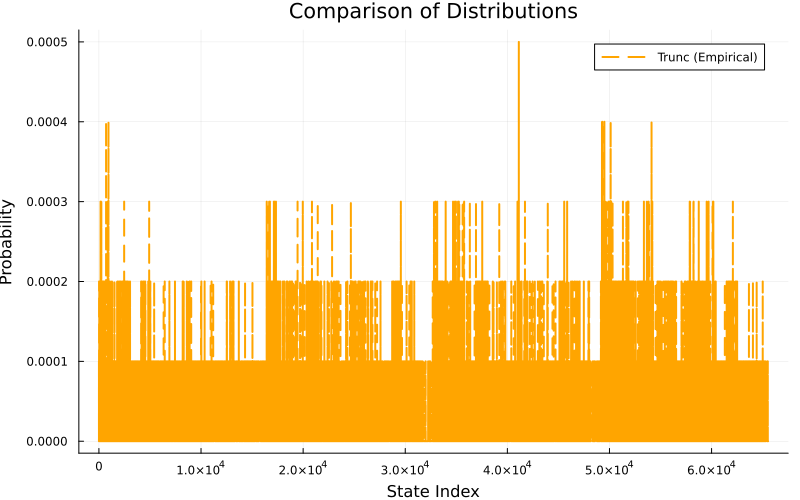

In [11]:
# Assuming your vectors are named:
# exact_exact, exact_emp, trunc_exact, trunc_emp

# Define x-axis (indices)
x = 1:2^nq

# Create a single plot object
p = plot(layout=(1,1), title="Comparison of Distributions", xlabel="State Index", ylabel="Probability", size=(800, 500))

# Add each series as a step plot
# 'lw' is linewidth, 'alpha' is transparency
# plot!(p, x, exactstate_exactsampling, seriestype=:step, label="Exact (Exact)", lw=2, color=:blue)
# plot!(p, x, exactstate_empiricalsampling,   seriestype=:step, label="Exact (Empirical)", lw=2, linestyle=:dash, color=:cyan)
# plot!(p, x, truncatedstate_exactsampling, seriestype=:step, label="Trunc (Exact)", lw=2, color=:red)
plot!(p, x, truncatedstate_empiricalsampling,   seriestype=:step, label="Trunc (Empirical)", lw=2, linestyle=:dash, color=:orange)

display(p)

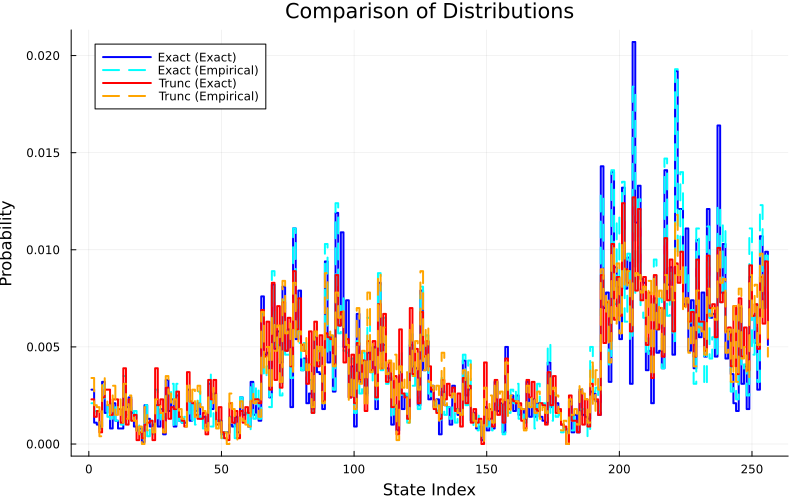

In [44]:
# Assuming your vectors are named:
# exact_exact, exact_emp, trunc_exact, trunc_emp

# Define x-axis (indices)
x = 1:2^nq

# Create a single plot object
p = plot(layout=(1,1), title="Comparison of Distributions", xlabel="State Index", ylabel="Probability", size=(800, 500))

# Add each series as a step plot
# 'lw' is linewidth, 'alpha' is transparency
plot!(p, x, exactstate_exactsampling, seriestype=:step, label="Exact (Exact)", lw=2, color=:blue)
plot!(p, x, exactstate_empiricalsampling,   seriestype=:step, label="Exact (Empirical)", lw=2, linestyle=:dash, color=:cyan)
plot!(p, x, truncatedstate_exactsampling, seriestype=:step, label="Trunc (Exact)", lw=2, color=:red)
plot!(p, x, truncatedstate_empiricalsampling,   seriestype=:step, label="Trunc (Empirical)", lw=2, linestyle=:dash, color=:orange)

display(p)

In [17]:
exactstate_exactsampling

16-element Vector{Float64}:
 0.044
 0.0741
 0.0216
 0.0384
 0.059
 0.1089
 0.03
 0.0448
 0.0744
 0.1295
 0.0388
 0.0534
 0.0723
 0.1257
 0.0325
 0.0526

In [18]:
exactstate_empiricalsampling

16-element Vector{Float64}:
 0.0421
 0.0781
 0.0232
 0.0295
 0.0628
 0.1102
 0.0287
 0.0477
 0.0746
 0.1269
 0.0356
 0.0598
 0.0693
 0.1259
 0.0312
 0.0544

In [19]:
truncatedstate_exactsampling

16-element Vector{Float64}:
 0.0868
 0.0891
 0.038
 0.0402
 0.0845
 0.0876
 0.041
 0.0366
 0.0868
 0.0842
 0.039
 0.0388
 0.0856
 0.0842
 0.0392
 0.0384

In [20]:
truncatedstate_empiricalsampling

16-element Vector{Float64}:
 0.0859
 0.0885
 0.0387
 0.0366
 0.0871
 0.0883
 0.0373
 0.0375
 0.087
 0.0863
 0.04
 0.0396
 0.0871
 0.0842
 0.0366
 0.0393

## larger system

In [45]:
nq = 10

field_scale = 0.5       # typical order of magnitude for 1-local terms
coupling_scale = 0.3    # typical order for 2-local terms
rng = MersenneTwister(30)

# Initialize all parameters randomly
params = parameters(
    :heisenberg_fields, nq;
    init = :randn,
    field_scale = field_scale,
    coupling_scale = coupling_scale,
    rng = rng
)

beta = 1

# beta = rand(rng, Uniform(1, 10))
qbm_H_paulis = makehamiltonian(params; connectivity=:nearest, periodic=false) * beta;
circuit, theta = paulistringtocircuit(qbm_H_paulis);
num_layers_qbm = nq * 10;

In [46]:
rho_exact = makethermalstate(nq, circuit, theta, num_layers_qbm;
                            max_weight=nq, min_abs_coeff=1e-10);

In [47]:
rho_truncated = makethermalstate(nq, circuit, theta, num_layers_qbm;
                            max_weight=nq/2, min_abs_coeff=1e-3);

In [48]:
samples = 10000

10000

In [49]:
counts = zeros(Int, 2^nq)

for _ in 1:samples
    bitstring = sample_bitstring(rho_exact; prob_method=:exact)
    index = foldl((acc, b) -> 2*acc + b, reverse(bitstring), init=0) + 1  # convert BitVector to index (1-based)
    counts[index] += 1
end

exactstate_exactsampling = counts ./ samples;

In [50]:
counts = zeros(Int, 2^nq)

for _ in 1:samples
    bitstring = sample_bitstring(rho_exact; prob_method=:approx)
    index = foldl((acc, b) -> 2*acc + b, reverse(bitstring), init=0) + 1  # convert BitVector to index (1-based)
    counts[index] += 1
end

exactstate_empiricalsampling = counts ./ samples;

In [51]:
counts = zeros(Int, 2^nq)

for _ in 1:samples
    bitstring = sample_bitstring(rho_truncated; prob_method=:exact)
    index = foldl((acc, b) -> 2*acc + b, reverse(bitstring), init=0) + 1  # convert BitVector to index (1-based)
    counts[index] += 1
end

truncatedstate_exactsampling = counts ./ samples;

In [52]:
counts = zeros(Int, 2^nq)

for _ in 1:samples
    bitstring = sample_bitstring(rho_truncated; prob_method=:approx)
    index = foldl((acc, b) -> 2*acc + b, reverse(bitstring), init=0) + 1  # convert BitVector to index (1-based)
    counts[index] += 1
end

truncatedstate_empiricalsampling = counts ./ samples;

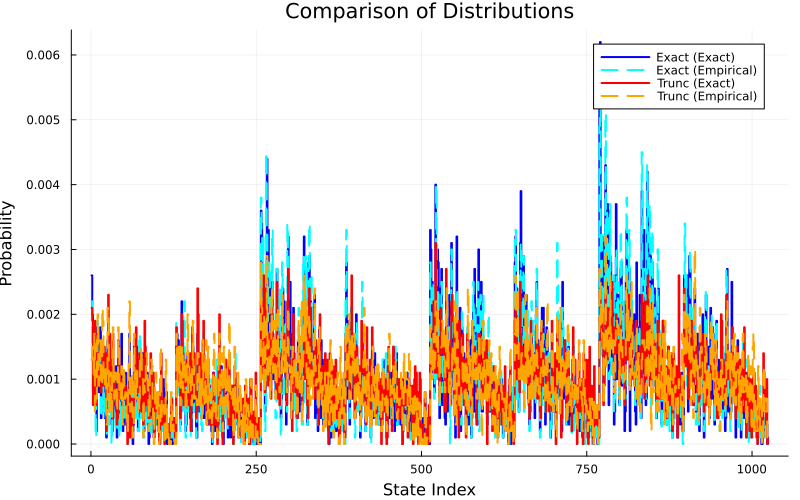

In [53]:
# Assuming your vectors are named:
# exact_exact, exact_emp, trunc_exact, trunc_emp

# Define x-axis (indices)
x = 1:2^nq

# Create a single plot object
p = plot(layout=(1,1), title="Comparison of Distributions", xlabel="State Index", ylabel="Probability", size=(800, 500))

# Add each series as a step plot
# 'lw' is linewidth, 'alpha' is transparency
plot!(p, x, exactstate_exactsampling, seriestype=:step, label="Exact (Exact)", lw=2, color=:blue)
plot!(p, x, exactstate_empiricalsampling,   seriestype=:step, label="Exact (Empirical)", lw=2, linestyle=:dash, color=:cyan)
plot!(p, x, truncatedstate_exactsampling, seriestype=:step, label="Trunc (Exact)", lw=2, color=:red)
plot!(p, x, truncatedstate_empiricalsampling,   seriestype=:step, label="Trunc (Empirical)", lw=2, linestyle=:dash, color=:orange)

display(p)

### The "Sorted" Plot (Best for Distribution Shape)

Instead of plotting by State Index (which is arbitrary), sort the x-axis by the probability of the "Exact (Exact)" distribution.

- Why it works: It turns the jagged blue line into a smooth, descending curve. You can then easily see if the other distributions (cyan, red, orange) follow the same curve or deviate.

- What to look for: If the empirical lines (dashed) are consistently above/below the solid lines in the "tail" (right side), it indicates sampling bias.

In [89]:
# 1. Sort based on Ground Truth
perm = sortperm(exactstate_exactsampling, rev=true)

sorted_exact_exact = exactstate_exactsampling[perm]
sorted_exact_emp   = exactstate_empiricalsampling[perm]
sorted_trunc_exact = truncatedstate_exactsampling[perm]
sorted_trunc_emp   = truncatedstate_empiricalsampling[perm]

# 2. Define a threshold for "Zero"
# Any value below this (like 0.0) becomes invisible
threshold = 1e-15

# Helper: Replace small values with NaN to break the line
mask_zeros(v) = [x <= threshold ? NaN : x for x in v]

# 3. Determine range (e.g., top 1000 or full length)
limit = min(2000, length(sorted_exact_exact))
range_inds = 1:limit

# 4. Plot
p = plot(title="Sorted Probability Distributions (N=12)", 
         xlabel="Sorted State Index", 
         ylabel="Probability", 
         yscale=:log10,
         legend=:topright, size=(800, 500))

# We do NOT need safe_log anymore because NaNs handle themselves
plot!(p, range_inds, mask_zeros(sorted_exact_exact[range_inds]), label="Exact (Exact)", lw=10, color=:blue)
# plot!(p, range_inds, mask_zeros(sorted_exact_emp[range_inds]),   label="Exact (Empirical)", lw=1.5, alpha=0.7, color=:cyan)
plot!(p, range_inds, mask_zeros(sorted_trunc_exact[range_inds]), label="Trunc (Exact)", lw=1, color=:red)
# plot!(p, range_inds, mask_zeros(sorted_trunc_emp[range_inds]),   label="Trunc (Empirical)", lw=1.5, alpha=0.7, color=:orange)

display(p)

### The Correlation Scatter Plot (Best for Accuracy)

Plot the Exact Probability (X-axis) versus the Empirical/Truncated Probability (Y-axis) for every state.
- Why it works: If the sampling is perfect, all points will fall exactly on the diagonal line $y=x$.
- What to look for:
  - Cloud width: Spread around the diagonal shows variance/noise.
  - Tilt: If the cloud is tilted, it means systematic bias (e.g., overestimating high probs, underestimating low probs).

In [92]:
using Plots
gr()
# 1. Define a threshold for "valid" data
threshold = 1e-15

# Helper function: Keep only points where BOTH x and y are valid (> threshold)
# This prevents passing NaNs or Zeros to the plotter entirely.
function get_valid_points(x_data, y_data)
    # Find indices where both x and y are above threshold
    valid_mask = (x_data .> threshold) .& (y_data .> threshold)
    return x_data[valid_mask], y_data[valid_mask]
end

# 2. Prepare the clean datasets
# Exact vs Empirical
x1, y1 = get_valid_points(exactstate_exactsampling, exactstate_empiricalsampling)

# Exact vs Truncated
x2, y2 = get_valid_points(exactstate_exactsampling, truncatedstate_exactsampling)

# 3. Create the Plot with EXPLICIT limits
# We enforce limits (e.g. 1e-6 to 1.1) so the axis tick calculator always has a valid range
p_scatter = plot(title="Correlation: Ground Truth vs Approximations",
                 xlabel="Ground Truth Probability",
                 ylabel="Approximation Probability",
                 xscale=:log10, 
                 yscale=:log10,
                 legend=:topleft, 
                 size=(600, 600), 
                 aspect_ratio=:equal,
                 xlims=(1e-6, 1.5), # Fixed limits prevent "No strict ticks" error
                 ylims=(1e-6, 1.5))

# 4. Reference Line y=x
plot!(p_scatter, [1e-6, 1.0], [1e-6, 1.0], 
      label="Ideal (y=x)", color=:black, lw=2, linestyle=:dash)

# 5. Plot the Cleaned Data
scatter!(p_scatter, x1, y1, 
         label="Exact vs Empirical", 
         color=:cyan, alpha=0.5, markersize=3, markerstrokewidth=0)

scatter!(p_scatter, x2, y2, 
         label="Exact vs Truncated", 
         color=:red, alpha=0.5, markersize=3, markerstrokewidth=0)

display(p_scatter)

### The Difference (Residual) Plot

Instead of plotting the raw values, plot the error ($\text{Approximation} - \text{Exact}$).
- Why it works: It removes the large vertical scale of the probabilities and lets you focus purely on "How wrong is this?"
- What to look for: Spikes indicate specific states where the approximation failed badly.

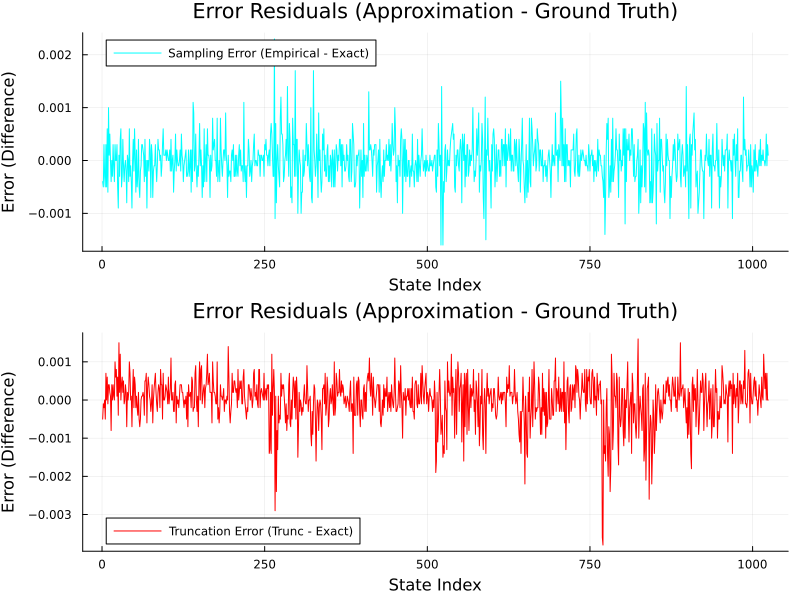

In [71]:
# Calculate differences relative to the Ground Truth
diff_exact_emp = exactstate_empiricalsampling .- exactstate_exactsampling
diff_trunc_exact = truncatedstate_exactsampling .- exactstate_exactsampling

p_diff = plot(title="Error Residuals (Approximation - Ground Truth)", 
              xlabel="State Index", ylabel="Error (Difference)", 
              layout=(2,1), size=(800, 600))

# Subplot 1: Sampling Error (Monte Carlo Noise)
plot!(p_diff[1], 1:2^nq, diff_exact_emp, label="Sampling Error (Empirical - Exact)", 
      color=:cyan, lw=1)

# Subplot 2: Truncation Error (Systematic Bias)
plot!(p_diff[2], 1:2^nq, diff_trunc_exact, label="Truncation Error (Trunc - Exact)", 
      color=:red, lw=1)

display(p_diff)

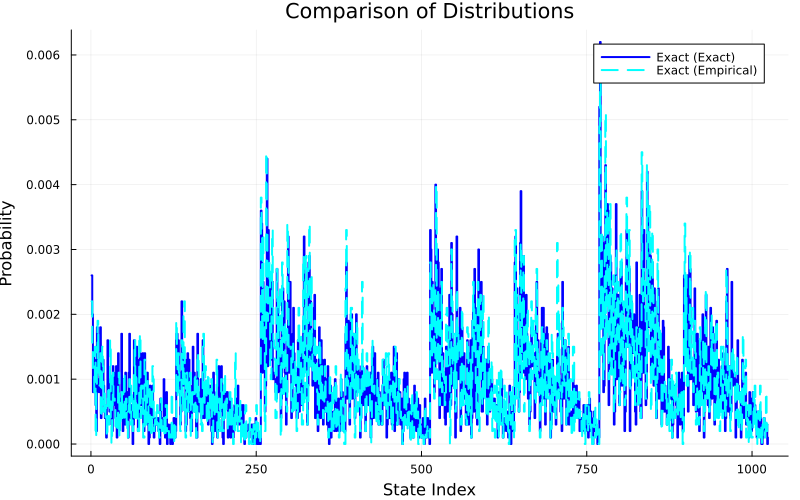

In [55]:
# Create a single plot object
p = plot(layout=(1,1), title="Comparison of Distributions", xlabel="State Index", ylabel="Probability", size=(800, 500))

# Add each series as a step plot
# 'lw' is linewidth, 'alpha' is transparency
plot!(p, x, exactstate_exactsampling, seriestype=:step, label="Exact (Exact)", lw=2, color=:blue)
plot!(p, x, exactstate_empiricalsampling,   seriestype=:step, label="Exact (Empirical)", lw=2, linestyle=:dash, color=:cyan)

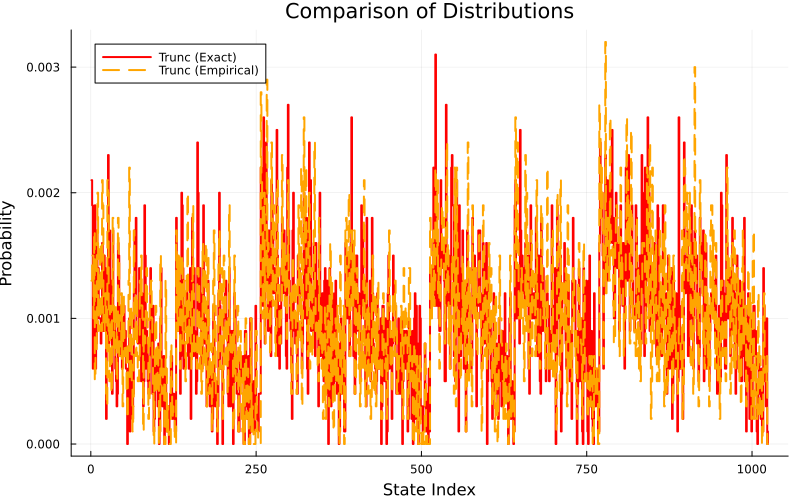

In [56]:
# Create a single plot object
p = plot(layout=(1,1), title="Comparison of Distributions", xlabel="State Index", ylabel="Probability", size=(800, 500))

# Add each series as a step plot
# 'lw' is linewidth, 'alpha' is transparency
plot!(p, x, truncatedstate_exactsampling, seriestype=:step, label="Trunc (Exact)", lw=2, color=:red)
plot!(p, x, truncatedstate_empiricalsampling,   seriestype=:step, label="Trunc (Empirical)", lw=2, linestyle=:dash, color=:orange)

In [58]:
"""
    total_variation_distance(p::Vector{Float64}, q::Vector{Float64})

Computes the Total Variation Distance (TVD) between two probability distributions.
TVD(P, Q) = 0.5 * sum(|P(x) - Q(x)|)
Range: [0, 1]
"""
function total_variation_distance(p::Vector{Float64}, q::Vector{Float64})
    if length(p) != length(q)
        error("Distributions must have the same length.")
    end
    return 0.5 * sum(abs.(p .- q))
end

"""
    kl_divergence(p::Vector{Float64}, q::Vector{Float64}; epsilon=1e-15)

Computes the Kullback-Leibler (KL) Divergence D_KL(P || Q).
D_KL(P || Q) = sum(P(x) * log(P(x) / Q(x)))

Arguments:
- `epsilon`: A small value added to Q(x) to prevent division by zero if Q(x)=0 but P(x)>0.
             Note: Technically, if Q(x)=0 and P(x)>0, KL is infinite. In numerics, we clip it.
"""
function kl_divergence(p::Vector{Float64}, q::Vector{Float64}; epsilon=1e-15)
    if length(p) != length(q)
        error("Distributions must have the same length.")
    end
    
    divergence = 0.0
    for i in 1:length(p)
        if p[i] > 0
            # If q[i] is 0, we use epsilon to avoid Inf
            q_val = max(q[i], epsilon)
            divergence += p[i] * log(p[i] / q_val)
        end
    end
    return divergence
end

kl_divergence

In [61]:
using Printf

# Your data
distributions = [
    ("Exact (Exact)",      exactstate_exactsampling),
    ("Exact (Approx)",     exactstate_empiricalsampling),
    ("Truncated (Exact)",  truncatedstate_exactsampling),
    ("Truncated (Approx)", truncatedstate_empiricalsampling)
]

num_dists = length(distributions)
tvd_matrix = zeros(Float64, num_dists, num_dists)

# Compute matrix
for i in 1:num_dists
    for j in 1:num_dists
        tvd_matrix[i, j] = total_variation_distance(distributions[i][2], distributions[j][2])
    end
end

# --- Robust Printing ---
println("\nTotal Variation Distance (TVD) Table:")
println("-"^95)

# 1. Print Header
# We use a fixed width of 22 chars for the row label column, and 18 for data columns
print(" "^22) 
for (name, _) in distributions
    @printf("%-18s", name)
end
println("\n" * "-"^95)

# 2. Print Rows
for i in 1:num_dists
    # Print the row label with fixed width padding
    @printf("%-22s", distributions[i][1])
    
    # Print the values
    for j in 1:num_dists
        val = tvd_matrix[i, j]
        if i == j
            @printf("%-18s", "-")
        else
            @printf("%-18.5f", val)
        end
    end
    println()
end
println("-"^95)


Total Variation Distance (TVD) Table:
-----------------------------------------------------------------------------------------------
                      Exact (Exact)     Exact (Approx)    Truncated (Exact) Truncated (Approx)
-----------------------------------------------------------------------------------------------
Exact (Exact)         -                 0.15990           0.21930           0.21530           
Exact (Approx)        0.15990           -                 0.21650           0.22090           
Truncated (Exact)     0.21930           0.21650           -                 0.17250           
Truncated (Approx)    0.21530           0.22090           0.17250           -                 
-----------------------------------------------------------------------------------------------


In [68]:
using Printf

# Your data
distributions = [
    ("Exact (Exact)",      exactstate_exactsampling),
    ("Exact (Approx)",     exactstate_empiricalsampling),
    ("Truncated (Exact)",  truncatedstate_exactsampling),
    ("Truncated (Approx)", truncatedstate_empiricalsampling)
]

num_dists = length(distributions)
kl_matrix = zeros(Float64, num_dists, num_dists)

# Compute matrix
for i in 1:num_dists
    for j in 1:num_dists
        kl_matrix[i, j] = kl_divergence(distributions[i][2], distributions[j][2])
    end
end

# --- Robust Printing ---
println("\nTotal Variation Distance (TVD) Table:")
println("-"^95)

# 1. Print Header
# We use a fixed width of 22 chars for the row label column, and 18 for data columns
print(" "^22) 
for (name, _) in distributions
    @printf("%-18s", name)
end
println("\n" * "-"^95)

# 2. Print Rows
for i in 1:num_dists
    # Print the row label with fixed width padding
    @printf("%-22s", distributions[i][1])
    
    # Print the values
    for j in 1:num_dists
        val = kl_matrix[i, j]
        if i == j
            @printf("%-18s", "-")
        else
            @printf("%-18.5f", val)
        end
    end
    println()
end
println("-"^95)


Total Variation Distance (TVD) Table:
-----------------------------------------------------------------------------------------------
                      Exact (Exact)     Exact (Approx)    Truncated (Exact) Truncated (Approx)
-----------------------------------------------------------------------------------------------
Exact (Exact)         -                 0.20662           0.29836           0.29852           
Exact (Approx)        0.18610           -                 0.29465           0.30205           
Truncated (Exact)     0.32807           0.35354           -                 0.28324           
Truncated (Approx)    0.25580           0.32167           0.21427           -                 
-----------------------------------------------------------------------------------------------


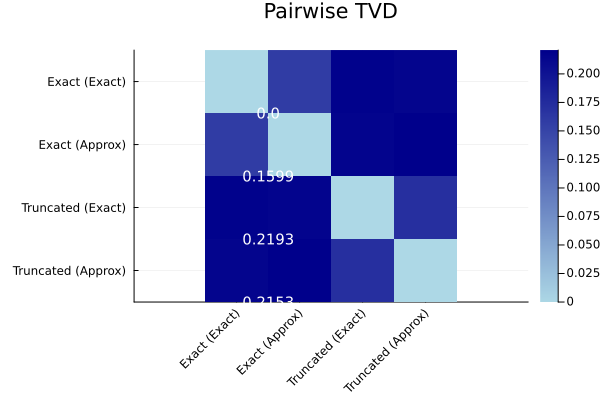

In [67]:
using Plots

# Create labels
names = [d[1] for d in distributions]

# Heatmap
p = heatmap(names, names, tvd_matrix, 
    title="Pairwise TVD", 
    color=:blues, 
    aspect_ratio=:equal, 
    yflip=true, # Puts index 1 at the top
    xrotation=45
)

# Annotate values
# FIX: Use `Plots.text` explicitly to avoid ambiguity
ann = [(j, i, Plots.text(round(tvd_matrix[i,j], digits=4), 10, :white, :center)) 
       for i in 1:num_dists, j in 1:num_dists]

plot!(p, annotation=ann)
display(p)